Files originally from https://github.com/LucasSilvaFerreira/Perturb_Loader


In [1]:
import mudata as md
import anndata as ad
import numpy as np
import pandas as pd
import perturbvi
import seaborn as sns
import scanpy as sc
import os
import pyro
from scipy.stats import norm
import matplotlib.pyplot as plt

smoke_test = False
data_dir = "../../../Data/gasperini_pilot"


/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Global seed set to 0


In [2]:
# load sceptre list of genes/guides


In [3]:
sceptre_df = pd.read_csv(f"{data_dir}/sceptre_results-2023_01_13.csv")
sceptre_df = sceptre_df.rename(columns={"gRNA_id": "guide", "gene_id": "gene", "z_value":"SCEPTRE_z_value","p_value":"SCEPTRE_p_value"})
selected_genes = sceptre_df["gene"].unique()
selected_guides = sceptre_df["guide"].unique()
print(len(selected_genes), len(selected_guides))
sceptre_df


5859 1243


,gene,guide,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change
0,Y_RNA,ACTB_TSS|1,positive_control,0.940707,1.632176,0.469126
1,FOXK1,ACTB_TSS|1,positive_control,0.153629,-0.992648,-0.088097
2,AP5Z1,ACTB_TSS|1,positive_control,0.123562,-1.010549,-0.119240
3,RADIL,ACTB_TSS|1,positive_control,0.057483,-1.501497,-0.386814
4,RNF216P1,ACTB_TSS|1,positive_control,0.341734,-0.635756,-0.034944
...,...,...,...,...,...,...
22261,SNORD60,scrambled_9|2,negative_control,0.950426,1.765242,0.708387
22262,DCAKD,scrambled_9|2,negative_control,0.488787,-0.149950,-0.027133
22263,RNF213-AS1,scrambled_9|2,negative_control,0.847978,1.018406,0.507472
22264,NAPB,scrambled_9|2,negative_control,0.696904,0.508168,0.149431


In [4]:
def construct_mudata(data_dir="."):
    rna_adata = ad.read_h5ad(f"{data_dir}/ann_exp.h5ad")
    rna_adata.obs["library_size"] = rna_adata.X.sum(axis=1)
    # rna_adata.obs["size_factor"] = rna_adata.obs["library_size"]
    rna_adata.varm["element_tested"] = ad.read_h5ad(f"{data_dir}/ann_Element_x_tested_genes.h5ad").to_df().T
    # sc.pp.filter_genes(rna_adata, min_cells=len(rna_adata)*0.1) # need genes where at least 10% of cells with nonzero counts
    grna_adata = ad.read_h5ad(f"{data_dir}/ann_guide.h5ad")
    grna_adata.varm["element_targeted"] = ad.read_h5ad(f"{data_dir}/ann_Element_guide.h5ad").to_df().T
    assert (rna_adata.varm["element_tested"].columns == grna_adata.varm["element_targeted"].columns).all()
    mdata = md.MuData({"rna": rna_adata, "grna": grna_adata})
    # mask = np.zeros(len(grna_adata))
    # mask[: int(len(grna_adata) * dilute_guides)] = 1.0
    # grna_adata.X = grna_adata.X * mask
    print(len(mdata))
    # downsample_idx = np.random.choice(len(mdata), size=int(len(mdata)*downsample_prob), replace=False)
    # mdata = mdata[downsample_idx, :]
    # mdata.write_h5mu(f"{data_dir}/gasperini_pilot_highMOI.h5mu")
    return mdata


force = True
mudata_file = "gasperini_pilot_highMOI.h5mu"
if mudata_file not in os.listdir(data_dir) or force:
    mdata = construct_mudata(data_dir)
else:
    mdata = md.read_h5mu(os.path.join(data_dir, mudata_file))
mdata


47964


MuData object with n_obs × n_vars = 47964 × 19482
  2 modalities
    rna:	47964 x 16367
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 3115
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [5]:
# mdata['grna'].varm['gene_targeted']
# mdata['rna'].varm['gene_tested']
mdata["grna"].varm["element_targeted"]


Element,ACTB_TSS,ACTG1_TSS,ACYP1_TSS,ADIPOR1_TSS,ALDH1A2_TSS,APEX1_TSS,APLP2_TSS,ARF6_TSS,ARID1A_TSS,ARL4A_TSS,...,scrambled_24,scrambled_25,scrambled_2,scrambled_3,scrambled_4,scrambled_5,scrambled_6,scrambled_7,scrambled_8,scrambled_9
ACTB_TSS|1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTB_TSS|2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACYP1_TSS|1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
scrambled_7|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
scrambled_8|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
scrambled_8|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
scrambled_9|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [6]:
guides = mdata["grna"].var_names
# selected_guides = list(guides[guides.str.contains(r"TSS|random|scrambled", regex=True)])

elements = list({guide.split("|")[0] for guide in selected_guides})
selected_elements = [e for e in elements if e in mdata["grna"].varm["element_targeted"].columns]
element_subset = mdata["grna"].varm["element_targeted"][selected_elements].copy()

grna_subset = mdata["grna"]
grna_subset.varm["element_targeted"] = element_subset

grna_subset = mdata["grna"][:, selected_guides]
# genes = list(sorted({e.split("_")[0] for e in selected_elements if "_TSS" in e}))
# subset_genes = [g for g in genes if g in mdata["rna"].var_names]
# print(selected_genes)

if smoke_test:
    selected_genes = ["KRT18"]  # DANGER SINGLE GENE ONLY
assert grna_subset.varm["element_targeted"].shape == (len(selected_guides), len(selected_elements))


In [7]:
grna_subset.varm["element_targeted"].shape


(1243, 625)

In [8]:
rna_subset = mdata["rna"]
rna_subset.varm["element_tested"] = rna_subset.varm["element_tested"][selected_elements].copy()
rna_subset = rna_subset[:, selected_genes]
mdata_subset = md.MuData({"rna": rna_subset.copy(), "grna": grna_subset.copy()})
assert (
    mdata_subset["rna"].varm["element_tested"].columns == mdata_subset["grna"].varm["element_targeted"].columns
).all()
mdata_subset


MuData object with n_obs × n_vars = 47964 × 1244
  2 modalities
    rna:	47964 x 1
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 1243
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [9]:
perturbvi.PERTURBVI.setup_mudata(
    mdata_subset,
    batch_key="bath_number",
    library_size_key="library_size",
    # size_factor_key="library_size",
    var_by_element_key="element_tested",
    perturb_by_element_key="element_targeted",
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

model = perturbvi.PERTURBVI(mdata_subset)
model.view_anndata_setup()


INFO     Using column names from columns of adata.varm['element_tested']                                           
INFO     Using column names from columns of adata.varm['element_targeted']                                         


Anndata setup with scvi-tools version 0.20.1.

Setup via `PERTURBVI.setup_anndata` with arguments:

{
│   'rna_layer': None,
│   'batch_key': 'bath_number',
│   'var_by_element_key': 'element_tested',
│   'perturb_by_element_key': 'element_targeted',
│   'perturbation_layer': None,
│   'modalities': {'rna_layer': 'rna', 'perturbation_layer': 'grna'},
│   'size_factor_key': None,
│   'library_size_key': 'library_size'
}

      Summary Statistics       
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃  Summary Stat Key   ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│       n_batch       │   6   │
│       n_cells       │ 47964 │
│   n_perturbations   │ 1243  │
│ n_targeted_elements │  625  │
│  n_tested_elements  │  625  │
│       n_vars        │   1   │
└─────────────────────┴───────┘

                          Data Registry                           
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃   Registry Key    ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         X         │             adata.mod['rna'].X             │
│       batch       │    adata.mod['rna'].obs['_scvi_batch']     │
│       ind_x       │       adata.mod['rna'].obs['_ind_x']       │
│   perturbations   │            adata.mod['grna'].X             │
│    size_factor    │    adata.mod['rna'].obs['_size_factor']    │
│ targeted_elements │ adata.mod['grna'].varm['element_targeted'] │
│  tested_elements  │  adata.mod['rna'].varm['element_tested']   │
└───────────────────┴────────────────────────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['bath_number'] │     1      │          0          │
│                          │     2      │          1          │
│                          │     3      │          2          │
│                          │     4      │          3          │
│                          │     5      │          4          │
│                          │     6      │          5          │
└──────────────────────────┴────────────┴─────────────────────┘

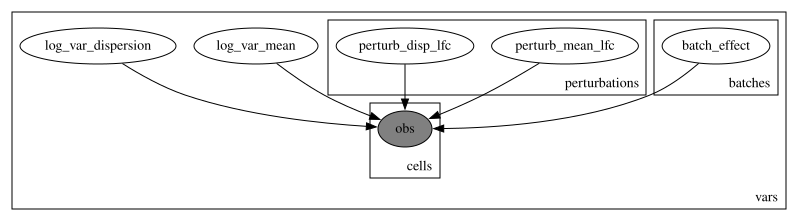

In [10]:
# requires graphviz to be installed
model.show_model()

In [11]:
mdata_subset["rna"].varm["element_tested"]
mdata_subset["grna"].varm["element_targeted"]


Element,CYB5B_TSS,random_4,chr11:5150664-5150687,chr14:75696446-75696469,UBC_TSS,NDUFB7_TSS,TMEM165_TSS,chr12:98972605-98972628,UQCRQ_TSS,chr13:50420653-50420676,...,JAGN1_TSS,PRKCB_TSS,ST6GALNAC1_TSS,chr11:129876786-129876809,MED10_TSS,SMS_TSS,chr11:61809436-61809459,RPL6_TSS,LYRM2_TSS,DYNC1I2_TSS
ACTB_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTB_TSS|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACYP1_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
scrambled_7|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
scrambled_8|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
scrambled_8|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
scrambled_9|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Model training

We can start out with a really high learning rate, then decrease the learning rate to fine-tune


In [12]:
# burn-in
model.train(10, lr=0.1, batch_size=1024)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:106: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 10/10: 100%|██████████| 10/10 [00:04<00:00,  2.09it/s, v_num=1, elbo_train=1.14e+5]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 10/10: 100%|██████████| 10/10 [00:04<00:00,  2.03it/s, v_num=1, elbo_train=1.14e+5]


In [13]:
# fine-tuning
model.train(50, lr=0.01, batch_size=8192)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:106: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/trainer.py:1609: PossibleUserWarning: The number of training batches (6) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower 

Epoch 50/50: 100%|██████████| 50/50 [00:08<00:00,  6.63it/s, v_num=1, elbo_train=1.05e+5]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [00:08<00:00,  6.17it/s, v_num=1, elbo_train=1.05e+5]


In [14]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)
    if sum(v.shape) <= 1:
        print(v)


log_var_mean.mu torch.Size([1])
tensor([-4.3165], requires_grad=True)
log_var_disp.mu torch.Size([1])
tensor([-1.3108], requires_grad=True)
batch_effect.mu torch.Size([6, 1])
batch_effect.sigma torch.Size([6, 1])
log_var_mean.sigma torch.Size([1])
tensor([0.0092], grad_fn=<AddBackward0>)
log_var_disp.sigma torch.Size([1])
tensor([0.0236], grad_fn=<AddBackward0>)
perturb_mean_lfc.mu torch.Size([1243, 1])
perturb_disp_lfc.mu torch.Size([1243, 1])
perturb_lfc.scale_tril torch.Size([1243, 1, 2, 2])


In [15]:
# plt.hist(pyro.get_param_store()["library_size_effect.mu"].cpu().detach().numpy())


In [16]:
%load_ext autoreload
%autoreload 2

lfc_threshold = 0.1 # ~ at least 10% knockdown
# lfc_threshold = 0 # nonzero knockdown
# gene_index=45

# scale_factor = 0.01
perturb_mean_lfc_mu = pyro.get_param_store()['perturb_mean_lfc.mu'].detach().cpu().numpy()
perturb_disp_lfc_mu = pyro.get_param_store()['perturb_disp_lfc.mu'].detach().cpu().numpy()
lfc_cov_tril = pyro.get_param_store()['perturb_lfc.scale_tril']
lfc_cov = lfc_cov_tril @ lfc_cov_tril.transpose(dim0=-1, dim1=-2)
perturb_mean_lfc_sigma = lfc_cov[...,0,0].sqrt().detach().cpu().numpy()
perturb_disp_lfc_sigma = lfc_cov[...,1,1].sqrt().detach().cpu().numpy()
assert perturb_mean_lfc_mu.shape == perturb_mean_lfc_sigma.shape
perturb_z_scores = perturb_mean_lfc_mu/perturb_mean_lfc_sigma
perturb_p_vals = norm.cdf(lfc_threshold, loc=-perturb_mean_lfc_mu, scale=perturb_mean_lfc_sigma)

def make_long_df(mat, value_name):
    return (
        pd.DataFrame(data=mat, columns=selected_genes, index=selected_guides)
        .melt(var_name="gene", value_name=value_name, ignore_index=False)
        .reset_index(names="guide")
        .assign(is_target=lambda x: x['guide'].str.split('_', expand=True)[0]==x['gene'])
    )
z_df = make_long_df(perturb_z_scores, "z_value")
p_df = make_long_df(perturb_p_vals, "p_value")

scpower_df = pd.merge(z_df, p_df)
scpower_df.sort_values("p_value")
# significant_results['guide'].str.split("_", expand=True)[0]
# significant_results.head(1000).to_excel("~/Downloads/significant_results.xlsx")

,guide,gene,z_value,is_target,p_value
279,KRT18_TSS|2,KRT18,-16.119532,True,4.403311e-50
278,KRT18_TSS|1,KRT18,-15.989342,True,7.098361e-50
138,DDX3X_TSS|1,KRT18,-5.473373,False,4.028436e-05
1045,chr13:29106285-29106308|2,KRT18,-3.171455,False,1.149415e-01
108,COMMD3_TSS|2,KRT18,-3.905384,False,1.242997e-01
...,...,...,...,...,...
148,DNAJB6_TSS|1,KRT18,3.787518,False,1.000000e+00
499,RABGGTB_TSS|1,KRT18,4.823541,False,1.000000e+00
862,chr11:33966182-33966205|2,KRT18,4.952538,False,1.000000e+00
593,SMS_TSS|2,KRT18,5.687328,False,1.000000e+00


In [17]:
lfc_cov_tril

tensor([[[[ 0.0288,  0.0000],
          [ 0.0034,  0.0778]]],


        [[[ 0.0321,  0.0000],
          [ 0.0031,  0.0715]]],


        [[[ 0.0375,  0.0000],
          [-0.0430,  0.0875]]],


        ...,


        [[[ 0.0440,  0.0000],
          [ 0.0067,  0.0829]]],


        [[[ 0.0354,  0.0000],
          [-0.0051,  0.0774]]],


        [[[ 0.0548,  0.0000],
          [-0.0034,  0.0930]]]], grad_fn=<AddBackward0>)

[]

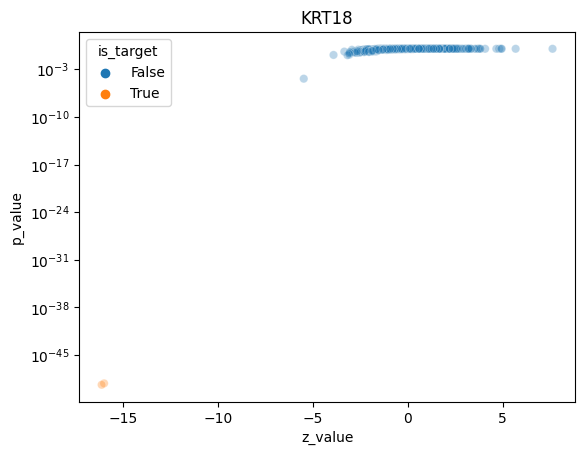

In [18]:
sns.scatterplot(
    scpower_df,
    hue="is_target",
    x="z_value",
    y="p_value",
    alpha=0.3
)
if smoke_test:
    plt.title(selected_genes[0])

plt.semilogy()
# significant_results.groupby("guide").count()['gene'].sort_values().tail(20)
# significant_results.to_excel("significant_results.xlsx")
# # perturb_z_scores[:,gene_index].detach().cpu().numpy()
# z_df = pd.DataFrame({'z_score': perturb_z_scores[:,gene_index],
#                     'mean_mu': perturb_mean_lfc_mu[:,gene_index],
#                     'disp_mu': perturb_disp_lfc_mu[:,gene_index],
#                     'mu_p_val': perturb_p_vals[:,gene_index],
#                     'grna': mdata_subset['grna'].var_names,})
# # z_df.hist('mu_p_val', bins=100)
# names[gene_index])
# print(z_df.sort_values('mu_p_val', ascending=True).reset_index(drop=True).head(20))


In [19]:
import matplotlib.pyplot as plt

# plt.scatter(pyro.get_param_store()["log_var_mean.mu"].cpu().detach().numpy(), pyro.get_param_store()["log_var_disp.mu"].cpu().detach().numpy(), alpha=0.1)


## Compare to SCEPTRE results


In [20]:
# merge_df=merge_df.assign(residual = lambda x: x['z_value']-x['value'])
# merge_df.sort_values('residual').tail(20)


[]

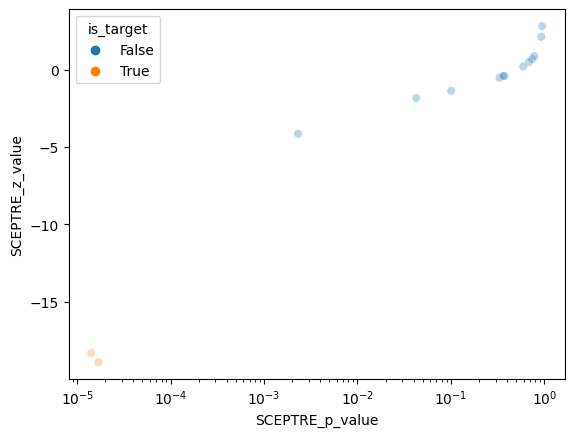

In [21]:
import matplotlib.pyplot as plt

merge_df = pd.merge(sceptre_df, scpower_df, how="inner")

sns.scatterplot(merge_df, x="SCEPTRE_p_value", y="SCEPTRE_z_value", hue="is_target", alpha=0.3)
plt.semilogx()

# plt.xlim([-40, 20])
# plt.ylim([-40, 20])

<Axes: xlabel='z_value', ylabel='SCEPTRE_z_value'>

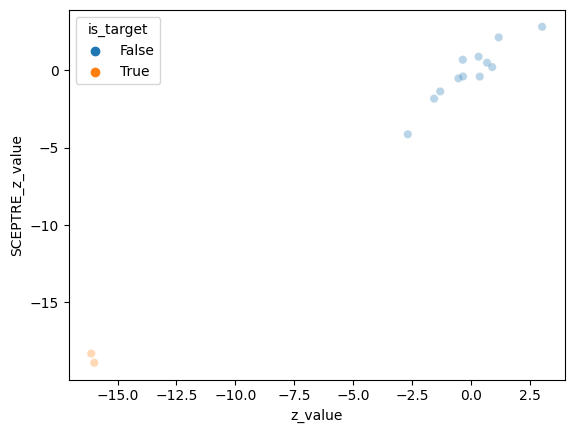

In [22]:
sns.scatterplot(merge_df, x="z_value", y="SCEPTRE_z_value", hue="is_target", alpha=0.3)


[]

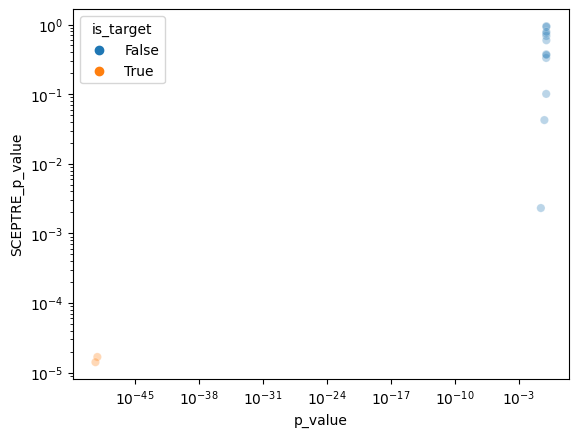

In [23]:
sns.scatterplot(merge_df, x="p_value", y="SCEPTRE_p_value", hue="is_target", alpha=0.3)
plt.loglog()

plot some genes


In [30]:
mdata_subset["grna"][:,"ACTB_TSS|1"]

View of AnnData object with n_obs × n_vars = 47964 × 1
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
    varm: 'element_targeted'

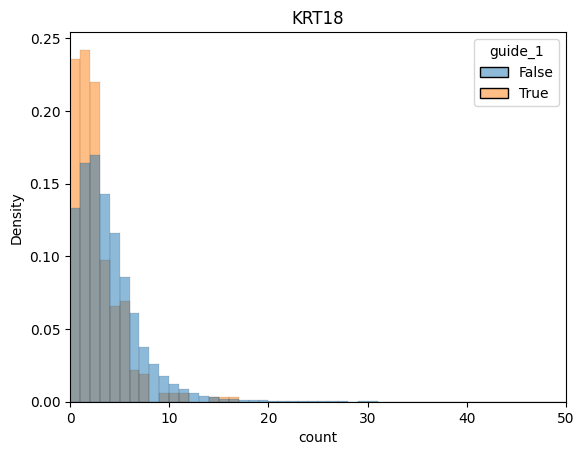

Text(0.5, 1.0, 'KRT18')

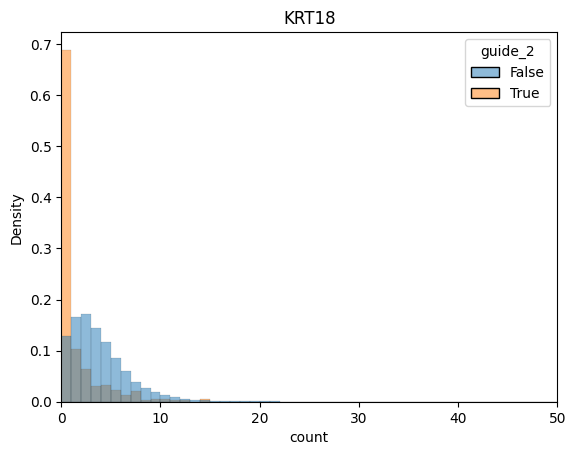

In [33]:
import scanpy as sc

plot_gene = selected_genes[0]
guide_1 = f"{plot_gene}_TSS|1"
guide_2 = f"{plot_gene}_TSS|2"
guide_1 = f"DDX3X_TSS|1"

counts = mdata_subset["rna"][:, plot_gene].X.todense().A1
guide_1_obs = mdata_subset["grna"][:, guide_1].X.astype(bool).squeeze()
guide_2_obs = mdata_subset["grna"][:, guide_2].X.astype(bool).squeeze()

plot_df = pd.DataFrame({"count": counts, "guide_1": guide_1_obs, "guide_2": guide_2_obs})
sns.histplot(
    plot_df,
    x="count",
    hue="guide_1",
    binwidth=1,
    common_norm=False,
    stat="density",
)
plt.xlim(0, 50)
plt.title(plot_gene)
plt.show()

sns.histplot(
    plot_df,
    x="count",
    hue="guide_2",
    binwidth=1,
    common_norm=False,
    stat="density",
)
plt.xlim(0, 50)
plt.title(plot_gene)
